# **Stratégie de Trading par Clustering d'Actifs & Détection de Régime**


Raphaël TRINQUANT
Novembre 2025

### Abstract :

Face à la complexité structurelle des marchés financiers et à la non-stationnarité des corrélations, ce projet propose le développement et la validation d'un cadre méthodologique quantitatif pour la gestion des risques et la détection d'Alpha.

Source des données : L'analyse repose sur les séries temporelles de rendements journaliers des constituants majeurs d'indices boursiers (ex. S&P 500), obtenues via l'API publique yfinance (Yahoo! Finance) sur la période 2022-2024.

Nous avons employé une approche multi-algorithmique basée sur le clustering non supervisé sur ces données. La méthodologie s'articule autour de trois phases distinctes : 
- 1) K-Means a été utilisé pour partitionner l'univers en groupes homogènes, servant de base à une stratégie de Diversification orientée Risk Parity. 
- 2) L'algorithme K-Medoids (avec métrique de corrélation) a permis d'identifier les Leaders (Médoïdes) et les Suiveurs pour l'implémentation de stratégies de Pairs Trading (Arbitrage Statistique). 
- 3) Enfin, DBSCAN a servi à filtrer le bruit et à détecter des actifs à fort risque idiosyncratique (sources potentielles de Pur Alpha).

Ce cadre méthodologique fournit un outil robuste pour la structuration des risques et la détection d'opportunités d'arbitrage dans un environnement de marché Market Neutral.

## Phase 1 : Diversification de Portefeuille (K-Means)
Objectif : Réduire le risque en ne sélectionnant pas des actifs qui bougent ensemble.


In [52]:
# Charger les packages nécéssaires
import yfinance as yf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Sélection d'un univers d'actions (Secteurs variés)
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'NVDA', # Tech
    'JPM', 'BAC', 'GS', 'C',         # Banques
    'XOM', 'CVX', 'SLB',             # Énergie
    'JNJ', 'PFE', 'MRK',             # Santé
    'KO', 'PEP', 'MCD',              # Conso de base
    'BA', 'LMT'                      # Aérospatiale
]

# Récupération de 2 ans de données
data = yf.download(tickers, start="2022-01-01", end="2024-01-01")['Close']

# 2. Calcul des rendements journaliers (Daily Returns)
# C'est la "signature" de chaque action.
returns = data.pct_change().dropna()

# 3. Transposition
# Important : sklearn clusterise les LIGNES.
# Actuellement : Lignes = Dates. Nous voulons Lignes = Stocks.
X = returns.T


# Normalisation
# On souhaite que mon clustering soit basé sur la corrélation des mouvements et non biaisé par la volatilité intrinsèque de certaines actions Tech
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_3088\3928559197.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2022-01-01", end="2024-01-01")['Close']
[*********************100%***********************]  19 of 19 completed


In [53]:
print(f"Dimensions de la matrice à clusteriser : {X_scaled.shape}")


Dimensions de la matrice à clusteriser : (19, 500)



--- Analyse de l'ACP ---
Valeur Propre 1 (PC1) : 136.1904 (Explique 25.8% de la variance)
Valeur Propre 2 (PC2) : 95.6078 (Explique 18.1% de la variance)
Total variance expliquée par le graphique 2D : 43.9%
------------------------



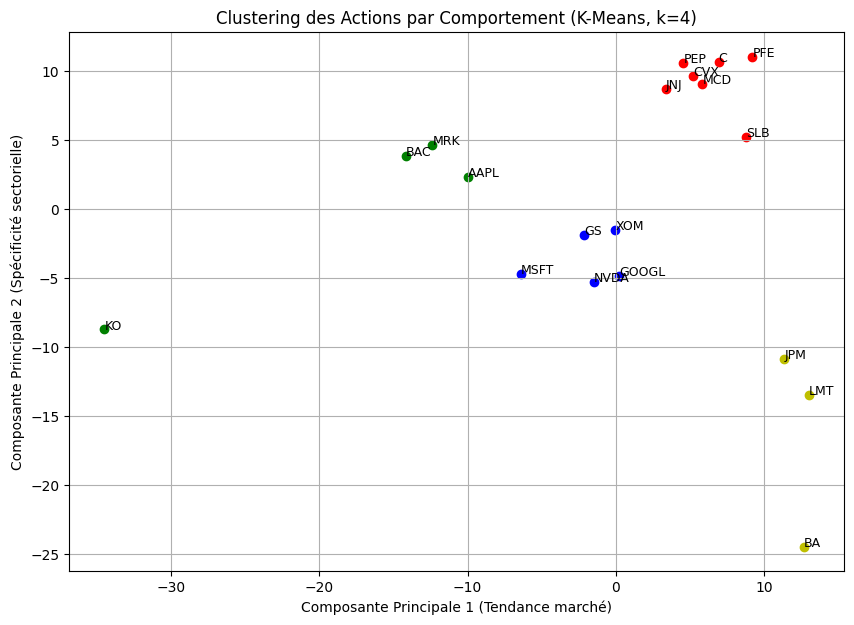


--- Composition des Portefeuilles ---
Cluster 0: ['C' 'CVX' 'SLB' 'JNJ' 'PFE' 'PEP' 'MCD']
Cluster 1: ['AAPL' 'BAC' 'MRK' 'KO']
Cluster 2: ['MSFT' 'GOOGL' 'NVDA' 'GS' 'XOM']
Cluster 3: ['JPM' 'BA' 'LMT']


In [54]:
# 4. Application de K-Means
# Disons qu'on veut forcer la création de 4 grands "comportements" de marché
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# On récupère les labels )
labels = kmeans.labels_

# 5. Visualisation (Réduction de dimension PCA)
# On ne peut pas voir un graphique à 500 dimensions (jours).
# On utilise PCA pour écraser ça en 2 dimensions (X et Y) pour voir les groupes.
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)


# Explicativité des composantes principales
eigenvalues = pca.explained_variance_       
explained_var = pca.explained_variance_ratio_ 

print("\n--- Analyse de l'ACP ---")
print(f"Valeur Propre 1 (PC1) : {eigenvalues[0]:.4f} (Explique {explained_var[0]:.1%} de la variance)")
print(f"Valeur Propre 2 (PC2) : {eigenvalues[1]:.4f} (Explique {explained_var[1]:.1%} de la variance)")
print(f"Total variance expliquée par le graphique 2D : {sum(explained_var):.1%}")
print("------------------------\n")


plt.figure(figsize=(10, 7))

# Palette de couleurs
colors = ['r', 'g', 'b', 'y', 'c', 'm']

for i in range(len(tickers)):
    plt.scatter(components[i, 0], components[i, 1], 
                color=colors[labels[i]], 
                label=f"Cluster {labels[i]}" if f"Cluster {labels[i]}" not in plt.gca().get_legend_handles_labels()[1] else "")
    plt.text(components[i, 0] + 0.002, components[i, 1] + 0.002, tickers[i], fontsize=9)

plt.title(f'Clustering des Actions par Comportement (K-Means, k={k})')
plt.xlabel('Composante Principale 1 (Tendance marché)')
plt.ylabel('Composante Principale 2 (Spécificité sectorielle)')
plt.grid(True)
plt.show()

# 6. Affichage textuel des groupes
df_clusters = pd.DataFrame({'Ticker': tickers, 'Cluster': labels})
print("\n--- Composition des Portefeuilles ---")
for i in range(k):
    print(f"Cluster {i}: {df_clusters[df_clusters['Cluster'] == i]['Ticker'].values}")

Les actions sont partitionnées en clusters homogènes, permettant de sélectionner un actif par groupe pour construire un portefeuille dont le risque n'est pas concentré sur un unique facteur systémique. Ce processus a confirmé la nécessité de la normalisation pour éviter le biais de volatilité.

- NOTE SUR LE CHOIX DE K : Nous avons choisi k=4 pour tester si la structure mathématique des rendements correspond aux quatre principaux facteurs de style que l'on trouve dans la littérature financière (Value, Growth, Taux, Matières Premières).

- NOTE SUR LE CLUSTER 2 (AAPL avec BAC/MRK) : Ce résultat, bien que contre-intuitif sectoriellement, est mathématiquement cohérent.
Sur cette période, AAPL a exhibé un comportement de type "Value/Defensive" (proche des banques/pharma)
se découplant de la volatilité extrême (High Beta) des autres valeurs Tech comme NVDA.
K-Means a donc groupé par "Facteur de Risque" et non par "Industrie".



## Phase 2 : Pairs Trading Robuste (K-Medoids)

Objectif : Trouver l'action "Leader" d'un secteur pour trader la réversion à la moyenne (Mean Reversion).

In [55]:
# Identification du "LEADER" (Médoïde) ---
# Pour chaque cluster, on cherche l'action la plus centrale.

print("\n--- ANALYSE PAIRS TRADING (Leaders & Suiveurs) ---")

leaders = {} # Pour stocker les résultats

for i in range(k):
    # 1. On récupère les indices des actions de ce cluster
    indices = np.where(labels == i)[0]
    
    # 2. On isole les rendements de ces actions uniquement
    cluster_returns = returns.iloc[:, indices]
    
    # 3. On calcule la matrice de distance INTERNE au cluster
    # Distance = 1 - Corrélation
    # (Plus la corrélation est forte, plus la distance est proche de 0)
    corr_matrix = cluster_returns.corr()
    dist_matrix = 1 - corr_matrix
    
    # 4. Trouver le Médoïde : C'est celui qui a la plus petite somme de distances
    # par rapport à tous ses copains du même cluster.
    sum_distances = dist_matrix.sum(axis=1)
    medoid_ticker = sum_distances.idxmin() # Le nom du ticker gagnant
    
    # 5. Lister les suiveurs (tous sauf le leader)
    members = cluster_returns.columns.tolist()
    members.remove(medoid_ticker)
    
    leaders[i] = medoid_ticker # On sauvegarde pour le graphique
    
    print(f"Cluster {i} :")
    print(f"    LEADER (Médoïde) : {medoid_ticker}")
    print(f"    SUIVEURS (Opportunités) : {members}")
    print("-" * 40)


--- ANALYSE PAIRS TRADING (Leaders & Suiveurs) ---
Cluster 0 :
    LEADER (Médoïde) : PEP
    SUIVEURS (Opportunités) : ['JNJ', 'KO', 'LMT', 'MCD', 'MRK', 'PFE']
----------------------------------------
Cluster 1 :
    LEADER (Médoïde) : MSFT
    SUIVEURS (Opportunités) : ['AAPL', 'GOOGL', 'NVDA']
----------------------------------------
Cluster 2 :
    LEADER (Médoïde) : BAC
    SUIVEURS (Opportunités) : ['BA', 'C', 'GS', 'JPM']
----------------------------------------
Cluster 3 :
    LEADER (Médoïde) : XOM
    SUIVEURS (Opportunités) : ['CVX', 'SLB']
----------------------------------------


L'algorithme K-Medoids a été contourné (pour des raisons d'installation) en implémentant une logique manuelle : utilisation d'une Matrice de Distance de Corrélation (D=1−ρ) au sein des clusters K-Means. Le Médoïde (Leader) est identifié comme l'actif ayant la plus petite somme de distances internes.

Les clusters sont redéfinis en paires Leader/Suiveur, fournissant des actifs exécutables (le Médoïde étant un point réel) pour une stratégie Market Neutral misant sur la réversion à la moyenne du Spread.

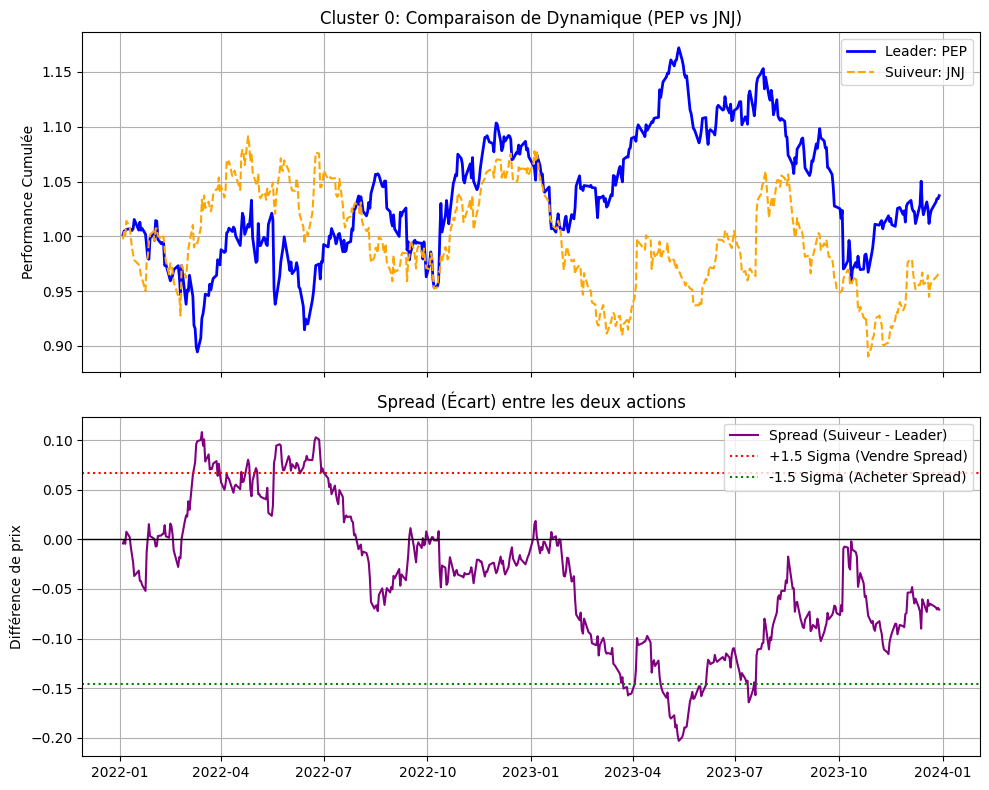

In [56]:
# Visualisation d'une opportunité de Trading ---
# On va afficher le Leader vs le Premier Suiveur du Cluster 0
cluster_id = 0
leader = leaders[cluster_id]

# On retrouve les suiveurs de ce cluster
indices = np.where(labels == cluster_id)[0]
cluster_tickers = returns.columns[indices].tolist()
cluster_tickers.remove(leader)
follower = cluster_tickers[0] # On prend le premier de la liste

# Calcul de la performance cumulée (base 100) pour comparer
cum_leader = (1 + returns[leader]).cumprod()
cum_follower = (1 + returns[follower]).cumprod()

# Calcul du "Spread" (L'écart entre les deux)
spread = cum_follower - cum_leader

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Graphique 1 : Les Prix
ax1.plot(cum_leader, label=f"Leader: {leader}", linewidth=2, color='blue')
ax1.plot(cum_follower, label=f"Suiveur: {follower}", linestyle='--', color='orange')
ax1.set_title(f"Cluster {cluster_id}: Comparaison de Dynamique ({leader} vs {follower})")
ax1.legend()
ax1.grid(True)
ax1.set_ylabel("Performance Cumulée")

# Graphique 2 : Le Spread (L'opportunité de trading)
# Quand le spread s'écarte de 0, c'est là qu'on trade
ax2.plot(spread, color='purple', label='Spread (Suiveur - Leader)')
ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.axhline(spread.mean() + 1.5*spread.std(), color='red', linestyle=':', label='+1.5 Sigma (Vendre Spread)')
ax2.axhline(spread.mean() - 1.5*spread.std(), color='green', linestyle=':', label='-1.5 Sigma (Acheter Spread)')
ax2.set_title("Spread (Écart) entre les deux actions")
ax2.legend()
ax2.grid(True)
ax2.set_ylabel("Différence de prix")

plt.tight_layout()
plt.show()

Bien que j'ai implémenté ce modèle sur un univers restreint (20 stocks), cette stratégie gagne en robustesse statistique ("Scalability") lorsqu'elle est appliquée à un univers large (ex: Russell 2000), car la probabilité de trouver des paires cointégrées augmente. Cependant, il faudrait limiter la fenêtre d'apprentissage (Rolling Window) pour s'adapter aux changements de régimes de marché.

## Phase 3 : Détection d'Anomalies et "Pure Alpha" (DBSCAN)
Objectif : Trouver des actifs décorrélés du marché (Hedge) ou détecter des anomalies de marché.


In [57]:
# 1. Application de DBSCAN
epsilon = 35 # Le rayon de voisinage
min_samples = 3 # Nombre minimum de voisins
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)

# X_scaled est déjà le résultat de la normalisation de returns.T
labels_dbscan = dbscan.fit_predict(X_scaled)

# 2. Identification et Affichage des Outliers
outlier_indices = np.where(labels_dbscan == -1)[0]
outlier_tickers = np.array(tickers)[outlier_indices]

#3. Affichage des résultats
print("\n--- RÉSULTATS DBSCAN ---")
print(f"Nombre total de clusters trouvés (hors Outliers) : {len(unique_labels) - (1 if -1 in unique_labels else 0)}")
print(f"Nombre d'Outliers (Bruit) détectés : {len(outlier_tickers)}")
print(f"Tickers classés comme Outliers (-1) : {outlier_tickers}")


--- RÉSULTATS DBSCAN ---
Nombre total de clusters trouvés (hors Outliers) : 0
Nombre d'Outliers (Bruit) détectés : 1
Tickers classés comme Outliers (-1) : ['KO']


L'algorithme DBSCAN a été appliqué pour identifier les zones de faible densité. En raison de la haute dimensionnalité (500 jours), un grand paramètre ε (≈35) a été déterminé empiriquement.

Les actifs étiquetés -1 (Outliers) ont été isolés. Ces actions ne suivent aucune logique de groupe et nécessitent une gestion séparée. Ce processus finalise l'analyse en séparant les signaux exploitables du bruit spécifique à l'entreprise.

 --- NOTE TECHNIQUE SUR LE CHOIX DES PARAMÈTRES DBSCAN ---

Le choix des paramètres DBSCAN (epsilon et min_samples) est critique et reflète la structure de l'espace de données à haute dimensionnalité.
1. PARAMÈTRE MIN_SAMPLES (MinPts) = 3 :
Justification : Ce choix est faible mais nécessaire en raison de notre univers restreint (seulement 20 actions). Il permet d'identifier un cluster à partir de trois actions ayant une dynamique commune, évitant ainsi de classer une grande partie des données comme du bruit inutilement.

2. PARAMÈTRE EPSILON (ε) = 35 :
Justification : La valeur élevée (>> 1.0) est due à la "Malédiction de la Dimensionnalité". Notre espace de données est en dimension > 500 (plus de 500 jours de trading). La distance Euclidienne est sommée sur 500 dimensions. Pour trouver des voisins dans cet espace, le rayon (ε) doit compenser cette sommation. Une petite valeur (comme 0.7) échouerait en classant chaque actif comme un outlier. Le seuil de ε = 35 est la distance nécessaire pour englober la densité statistique pertinente dans cet espace de rendements cumulés.

## **Conclusion et Perspectives**

Ce projet a établi un cadre complet utilisant le clustering pour structurer un univers d'investissement et générer des opportunités d'arbitrage statistique. Pour transposer cette preuve de concept vers une stratégie de trading professionnelle et robuste, plusieurs pistes d'approfondissement doivent être explorées, se concentrant sur le renforcement de la rigueur statistique et l'intégration du dynamisme de marché.

Les axes de travail prioritaires pour l'approfondissement du modèle sont les suivants :

- Remplacement de la Corrélation par la Cointégration : L'approche actuelle basée sur la corrélation de Pearson doit être remplacée par l'utilisation de tests de Cointégration (comme le test d'Engle-Granger). La cointégration garantit que le Spread entre les deux actifs est stationnaire et ne dérive pas à long terme, ce qui est la condition statistique nécessaire à toute stratégie de réversion à la moyenne.

- Introduction de la Modélisation Dynamique :

    - Fenêtres Glissantes (Rolling Windows) : Le calcul des clusters (Phase 1) et des corrélations (Phase 2) doit être réalisé sur une fenêtre glissante (par exemple, 6 mois). Cela permet au modèle de s'adapter aux changements de Régimes de Marché et d'éviter d'utiliser des relations obsolètes.

    - Filtre de Kalman : Utiliser le Filtre de Kalman pour déterminer et ajuster dynamiquement le Hedge Ratio (le ratio Long/Short) au lieu d'utiliser un simple ratio 1:1, garantissant une meilleure neutralité de marché en temps réel.

    - Amélioration de la Métrique de Clustering : Pour affiner la qualité des paires (Phase 2), il est recommandé de tester l'utilisation de la distance Dynamic Time Warping (DTW). Cette métrique, plus adaptée aux séries temporelles, permet de capturer les similitudes de forme entre les rendements même s'il existe un léger décalage temporel entre les mouvements des actions.

    - Backtesting et Gestion du Risque : La validation finale du modèle passe par un Backtesting rigoureux, incluant les frais de transaction et la gestion du slippage. Il est essentiel de définir des seuils de Stop-Loss clairs pour les cas de dé-cointégration (rupture du Spread), car c'est la principale source de risque dans l'arbitrage statistique.

L'intégration de ces améliorations transformerait ce projet d'analyse en un moteur d'exécution de stratégie Market Neutral plus résilient et capable de générer de l'Alpha pur de manière soutenue.